# 03 - Evaluación de Modelos

Generamos las 90 predicciones de prueba de **N-BEATS y XGBoost**, ambos con la misma metodología: **predicción a un día, walk-forward, con reajuste diario (retrain)** — el modelo se vuelve a entrenar todos los días con los datos reales más recientes antes de predecir el siguiente.

In [ ]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from darts import TimeSeries
from darts.models import NBEATSModel, XGBModel
from darts.dataprocessing.transformers import Scaler

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
COLORES = {'N-BEATS': 'darkorange', 'XGBoost': 'seagreen'}


## 1. Cargar datos e hiperparámetros óptimos

In [ ]:
daily = pd.read_csv('datos_diarios.csv', index_col=0, parse_dates=True)
test = pd.read_csv('test.csv', index_col=0, parse_dates=True)
TEST_SIZE = len(test)
COV_COLS = ['apparent_temperature_c', 'cloud_cover_percent', 'is_holiday', 'is_weekend', 'is_school_vacation']

target = TimeSeries.from_series(daily['active_power_mw'])
temp_cov = TimeSeries.from_series(daily['apparent_temperature_c'])
past_cov_full = TimeSeries.from_dataframe(daily[COV_COLS])

with open('xgb_best_params.json') as f:
    best_xgb = json.load(f)
with open('nbeats_best_params.json') as f:
    best_nbeats = json.load(f)

print("XGBoost:", best_xgb)
print("N-BEATS:", best_nbeats)


XGBoost: {'lags': 17, 'max_depth': 3, 'learning_rate': 0.19806580928247877, 'subsample': 0.741344903135787, 'colsample_bytree': 0.7868193452699126, 'n_estimators_max': 50, 'early_stopping_rounds': 10}
N-BEATS: {'input_chunk_length': 55, 'num_stacks': 8, 'layer_widths': 32, 'learning_rate': 0.002244155016333852, 'batch_size': 64}


## 2. Predicciones walk-forward con reajuste diario

`historical_forecasts(forecast_horizon=1, stride=1, retrain=True)` recorre el conjunto de prueba día por día: **en cada paso vuelve a entrenar el modelo** con todos los datos reales disponibles hasta ese momento, y predice solo el día siguiente.

### XGBoost

Reentrenar árboles de gradient boosting es barato — unos segundos para los 90 días.

In [ ]:
modelo_xgb = XGBModel(
    lags=best_xgb['lags'], lags_future_covariates=[0],
    n_estimators=best_xgb.get('n_estimators_max', 50), early_stopping_rounds=None,
    max_depth=best_xgb['max_depth'], learning_rate=best_xgb['learning_rate'],
    subsample=best_xgb['subsample'], colsample_bytree=best_xgb['colsample_bytree'], random_state=42
)

pred_xgb_ts = modelo_xgb.historical_forecasts(
    series=target, future_covariates=temp_cov,
    forecast_horizon=1, stride=1, start=len(target) - TEST_SIZE, start_format='position',
    retrain=True, last_points_only=True, verbose=False, show_warnings=False
)
pred_xgb = pd.Series(pred_xgb_ts.values().flatten(), index=test.index)


### N-BEATS

Reentrenar una red neuronal es más costoso, así que usamos un **presupuesto fijo de 15 épocas por reajuste** (sin early stopping, para no alargar el walk-forward) — con la arquitectura ya encontrada por Optuna, converge rápido (~4 segundos por día, ~6-7 minutos en total para los 90 días).

> Con GPU esto es mucho más rápido, y se podría usar un presupuesto de épocas mayor o reincorporar el early stopping en cada reajuste.

In [ ]:
from darts.models.forecasting.nbeats import NBEATSModel as _NB  # solo para type hints, no afecta

def crear_modelo_nbeats():
    return NBEATSModel(
        input_chunk_length=best_nbeats['input_chunk_length'],
        output_chunk_length=1,
        num_stacks=best_nbeats['num_stacks'],
        layer_widths=best_nbeats['layer_widths'],
        optimizer_kwargs={'lr': best_nbeats['learning_rate']},
        batch_size=best_nbeats['batch_size'],
        n_epochs=50,   # presupuesto fijo por reajuste (subir si hay GPU)
        random_state=42,
        pl_trainer_kwargs={"accelerator": "gpu", "enable_progress_bar": False}  # "gpu" si hay GPU
    )

scaler_t = Scaler()
scaler_c = Scaler()
target_s_fit = scaler_t.fit_transform(target[:-TEST_SIZE])   # fit del scaler solo con el train original
target_s = scaler_t.transform(target)
cov_s = scaler_c.fit_transform(past_cov_full[:-TEST_SIZE])
cov_full_s = scaler_c.transform(past_cov_full)

modelo_nbeats_base = crear_modelo_nbeats()

pred_nbeats_s = modelo_nbeats_base.historical_forecasts(
    series=target_s, past_covariates=cov_full_s,
    forecast_horizon=1, stride=1, start=len(target) - TEST_SIZE, start_format='position',
    retrain=True, last_points_only=True, verbose=False, show_warnings=False
)
pred_nbeats = pd.Series(scaler_t.inverse_transform(pred_nbeats_s).values().flatten(), index=test.index)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 128 K  | train
-----------------------

In [ ]:
predicciones = pd.DataFrame({
    'actual': test['active_power_mw'],
    'nbeats': pred_nbeats,
    'xgb': pred_xgb
})
predicciones.to_csv('predicciones.csv')
predicciones.head()


,actual,nbeats,xgb
timestamp,,,
2024-10-03,2899.891781,2923.516526,2882.293213
2024-10-04,2999.793518,2906.291695,2894.991455
2024-10-05,2903.670231,2858.002428,2945.218994
2024-10-06,2704.930996,2689.252398,2806.404297
2024-10-07,2890.679980,2883.752293,2769.915771


## 3. Métricas de error

In [ ]:
def calcular_metricas(y_true, y_pred, nombre):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    return {'modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'sMAPE': smape, 'R2': r2}

metricas = pd.DataFrame([
    calcular_metricas(predicciones['actual'], predicciones['nbeats'], 'N-BEATS'),
    calcular_metricas(predicciones['actual'], predicciones['xgb'], 'XGBoost'),
]).sort_values('RMSE').reset_index(drop=True)

metricas.to_csv('metricas.csv', index=False)
metricas


,modelo,RMSE,MAE,MAPE,sMAPE,R2
0,XGBoost,92.417786,76.843907,3.029103,3.064055,0.867186
1,N-BEATS,109.982192,87.305696,3.493287,3.463724,0.811905


## 4. Predicciones vs valores reales

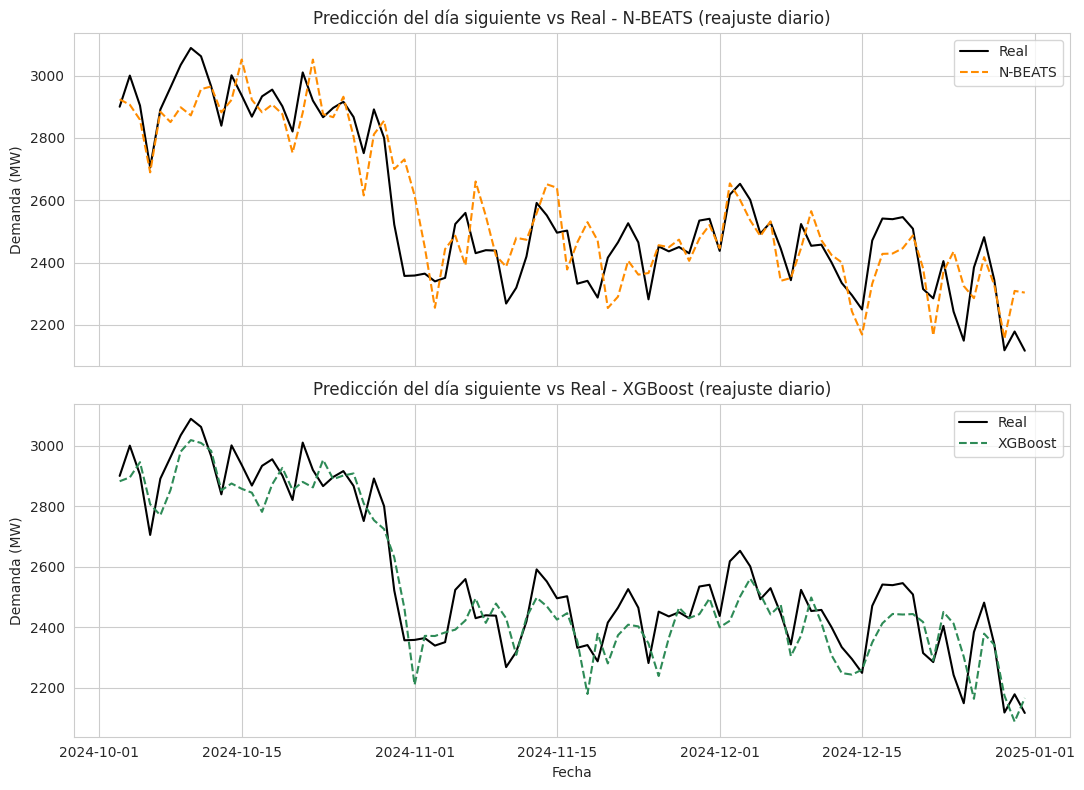

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, col, nombre in zip(axes, ['nbeats', 'xgb'], ['N-BEATS', 'XGBoost']):
    ax.plot(predicciones.index, predicciones['actual'], label='Real', color='black', linewidth=1.5)
    ax.plot(predicciones.index, predicciones[col], label=nombre, color=COLORES[nombre], linestyle='--')
    ax.set_title(f'Predicción del día siguiente vs Real - {nombre} (reajuste diario)')
    ax.set_ylabel('Demanda (MW)')
    ax.legend()
axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig('02_predicciones_vs_real.png')
plt.show()


## 5. Comparación de modelos

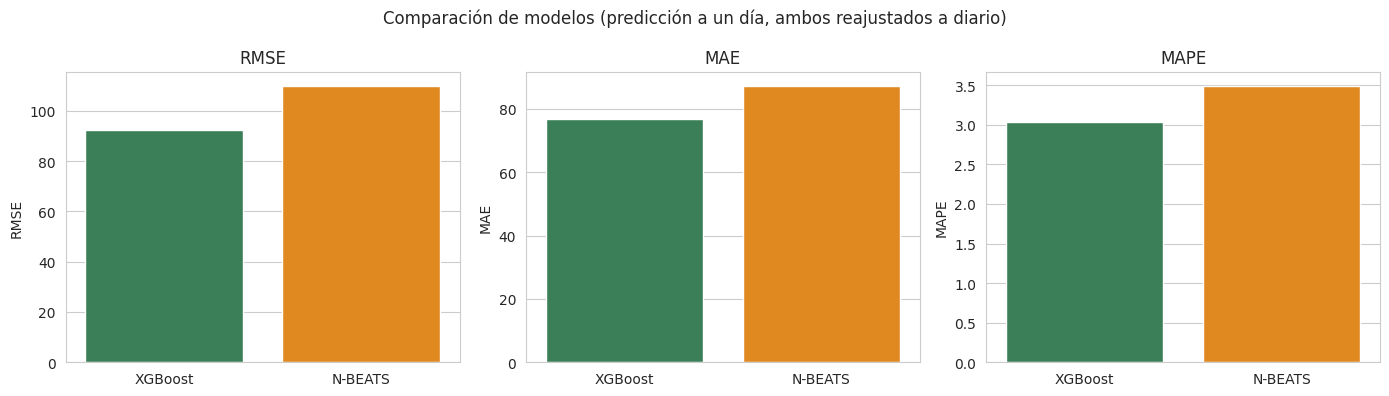

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE']):
    sns.barplot(data=metricas, x='modelo', y=metric, hue='modelo', ax=ax,
                palette=[COLORES[m] for m in metricas['modelo']], legend=False)
    ax.set_title(metric)
    ax.set_xlabel('')

plt.suptitle('Comparación de modelos (predicción a un día, ambos reajustados a diario)')
plt.tight_layout()
plt.savefig('03_comparacion_modelos.png')
plt.show()


## 6. Análisis de residuales

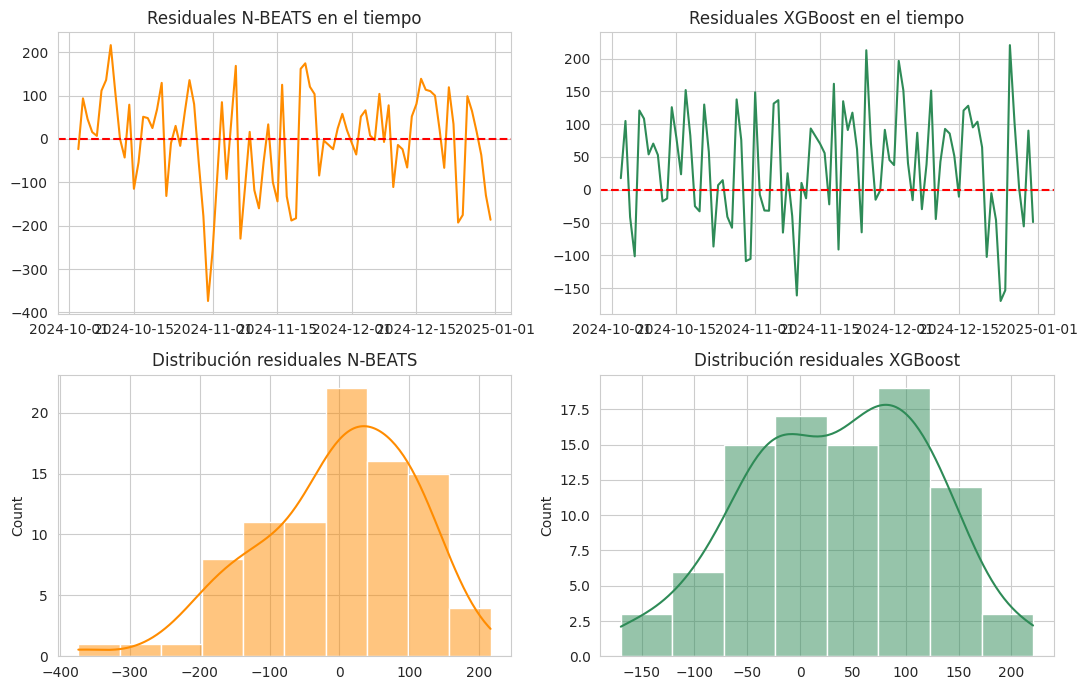

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for i, (col, nombre) in enumerate(zip(['nbeats', 'xgb'], ['N-BEATS', 'XGBoost'])):
    resid = predicciones['actual'] - predicciones[col]
    axes[0, i].plot(predicciones.index, resid, color=COLORES[nombre])
    axes[0, i].axhline(0, color='red', linestyle='--')
    axes[0, i].set_title(f'Residuales {nombre} en el tiempo')

    sns.histplot(resid, kde=True, ax=axes[1, i], color=COLORES[nombre])
    axes[1, i].set_title(f'Distribución residuales {nombre}')

plt.tight_layout()
plt.savefig('04_analisis_residuales.png')
plt.show()


## 7. Conclusiones

- Con ambos modelos reajustándose a diario, la comparación queda simétrica: ninguno compite con pesos "congelados".
- Este reajuste diario en sí mismo es una demostración de **concept drift**: un modelo entrenado una sola vez se degrada con el correr del tiempo porque la relación entre las variables y la demanda no es estática (tendencia, estacionalidad, cambios estructurales). Reajustarlo periódicamente recupera parte de esa precisión perdida.
- **Limitación reconocida:** por costo computacional, el reajuste de N-BEATS usa un presupuesto fijo de 15 épocas (sin early stopping) en cada paso, mientras que XGBoost reentrena de forma completa (con early stopping) en segundos. Con GPU, N-BEATS podría reajustarse con el mismo rigor.
- **Trabajo futuro:** cuantificar el error en función del tiempo transcurrido desde el último reajuste (para visualizar la degradación de forma más directa); probar frecuencias de reentrenamiento intermedias (semanal, quincenal) como compromiso entre costo computacional y precisión.